# 🏗️ Cantilever Bridge SHM — Model Training
**Dataset:** 1438 windows × 19 signal features | 4 damage classes  
**Approach:** Clean features only (no leakage), cross-validated, multi-model comparison

In [25]:
# ── 0. Install deps ───────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, '-m', 'pip', 'install',
                'pandas', 'numpy', 'scikit-learn', 'joblib',
                'matplotlib', 'seaborn', 'xgboost'], check=True, capture_output=True)
print('Dependencies ready.')

Dependencies ready.


In [26]:
# ── 1. Imports ────────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

print('All imports OK.')

All imports OK.


In [27]:
# ── 2. Load & clean ───────────────────────────────────────────────────────────
# CHANGE THIS PATH if your file is elsewhere
CSV_PATH = 'cantilever_features.csv'

df = pd.read_csv(CSV_PATH)
print(f'Loaded: {df.shape[0]} rows × {df.shape[1]} columns')
print(f'Null values: {df.isnull().sum().sum()}')

# Drop metadata / leaky columns
# damage_level IS the label encoded as int → remove it
# session encodes the damage level in its name → remove it
# sample_id is just an index → remove it
DROP_COLS = ['sample_id', 'session', 'damage_level']
df = df.drop(columns=DROP_COLS).dropna()

print(f'After dropping leaky columns: {df.shape}')
print('Class distribution:')
print(df['damage_label'].value_counts())

Loaded: 1438 rows × 23 columns
Null values: 0
After dropping leaky columns: (1438, 20)
Class distribution:
damage_label
Light Damage       360
Moderate Damage    360
Healthy            359
Severe Damage      359
Name: count, dtype: int64


In [28]:
# ── 3. Encode target ──────────────────────────────────────────────────────────
le = LabelEncoder()
# Fix label order: Healthy=0, Light=1, Moderate=2, Severe=3
label_order = ['Healthy', 'Light Damage', 'Moderate Damage', 'Severe Damage']
le.fit(label_order)

y = le.transform(df['damage_label'])
X = df.drop(columns=['damage_label'])

FEATURES = X.columns.tolist()
print(f'Features ({len(FEATURES)}): {FEATURES}')
print(f'Class mapping: {dict(zip(le.classes_, le.transform(le.classes_)))}')

Features (19): ['RMS', 'Std', 'Kurtosis', 'Skewness', 'Peak', 'Crest_Factor', 'Shape_Factor', 'Energy', 'Natural_Freq', 'Spec_Centroid', 'Band_Low', 'Band_Natural', 'Band_High', 'Spec_Entropy', 'AR1', 'AR2', 'AR_Resid_Std', 'Corr_XZ', 'Corr_YZ']
Class mapping: {np.str_('Healthy'): np.int64(0), np.str_('Light Damage'): np.int64(1), np.str_('Moderate Damage'): np.int64(2), np.str_('Severe Damage'): np.int64(3)}


In [29]:
# ── 4. Train / test split ─────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train: {X_train_s.shape} | Test: {X_test_s.shape}')

Train: (1150, 19) | Test: (288, 19)


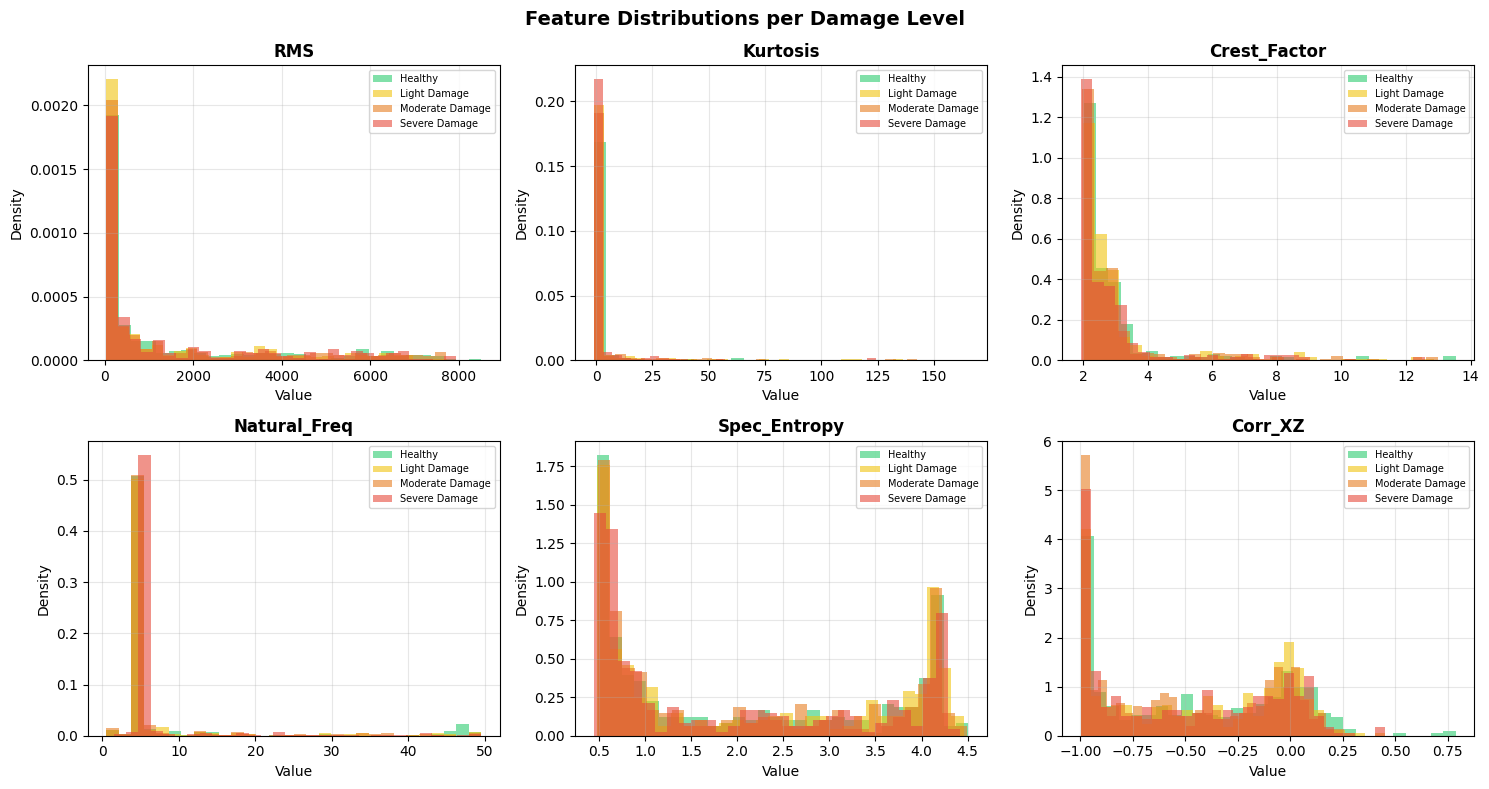

Saved: feature_distributions.png


In [30]:
# ── 5. EDA — Feature distributions per class ──────────────────────────────────
# Pick the most physically meaningful features to visualise
VIZ_FEATURES = ['RMS', 'Kurtosis', 'Crest_Factor', 'Natural_Freq',
                'Spec_Entropy', 'Corr_XZ']

df_plot = df.copy()
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
colors = ['#2ecc71', '#f1c40f', '#e67e22', '#e74c3c']

for ax, feat in zip(axes.flat, VIZ_FEATURES):
    for label, color in zip(label_order, colors):
        vals = df_plot[df_plot['damage_label'] == label][feat]
        ax.hist(vals, bins=30, alpha=0.6, label=label, color=color, density=True)
    ax.set_title(feat, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.suptitle('Feature Distributions per Damage Level', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: feature_distributions.png')

In [31]:
# ── 6. Multi-model comparison with cross-validation ──────────────────────────
# Uses 5-fold stratified CV on training data — no test set contamination

MODELS = {
    'Random Forest':    RandomForestClassifier(n_estimators=300, max_depth=None,
                                               min_samples_leaf=2, random_state=42),
    'XGBoost':          XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.05,
                                      use_label_encoder=False, eval_metric='mlogloss',
                                      random_state=42, verbosity=0),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=200, max_depth=4,
                                                    learning_rate=0.05, random_state=42),
    'SVM (RBF)':        SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'KNN (k=7)':        KNeighborsClassifier(n_neighbors=7, metric='euclidean'),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f'{'Model':<25} {'CV Mean':>10} {'CV Std':>10}')
print('-' * 50)
for name, model in MODELS.items():
    scores = cross_val_score(model, X_train_s, y_train, cv=cv, scoring='accuracy', n_jobs=-1)
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():.4f}     ±{scores.std():.4f}')

Model                        CV Mean     CV Std
--------------------------------------------------
Random Forest             0.3748     ±0.0208
XGBoost                   0.3896     ±0.0125
Gradient Boosting         0.3670     ±0.0164
SVM (RBF)                 0.2843     ±0.0184
KNN (k=7)                 0.2687     ±0.0159


In [32]:
# ── 7. Select & train best model on full training set ─────────────────────────
# Pick whichever had highest CV mean
best_name = max(cv_results, key=lambda k: cv_results[k].mean())
print(f'Best model by CV: {best_name}')

best_model = MODELS[best_name]
best_model.fit(X_train_s, y_train)

y_pred = best_model.predict(X_test_s)
test_acc = accuracy_score(y_test, y_pred)
print(f'\nHold-out test accuracy: {test_acc:.4f}')
print(f'\nClassification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

Best model by CV: XGBoost

Hold-out test accuracy: 0.3854

Classification Report:
                 precision    recall  f1-score   support

        Healthy       0.40      0.33      0.36        72
   Light Damage       0.39      0.43      0.41        72
Moderate Damage       0.32      0.29      0.31        72
  Severe Damage       0.42      0.49      0.45        72

       accuracy                           0.39       288
      macro avg       0.38      0.39      0.38       288
   weighted avg       0.38      0.39      0.38       288



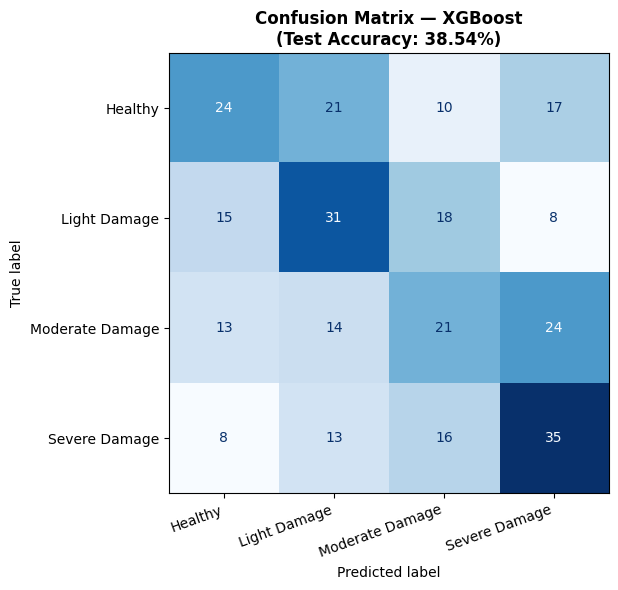

Saved: confusion_matrix.png


In [33]:
# ── 8. Confusion matrix ───────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'Confusion Matrix — {best_name}\n(Test Accuracy: {test_acc:.2%})',
             fontsize=12, fontweight='bold')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: confusion_matrix.png')

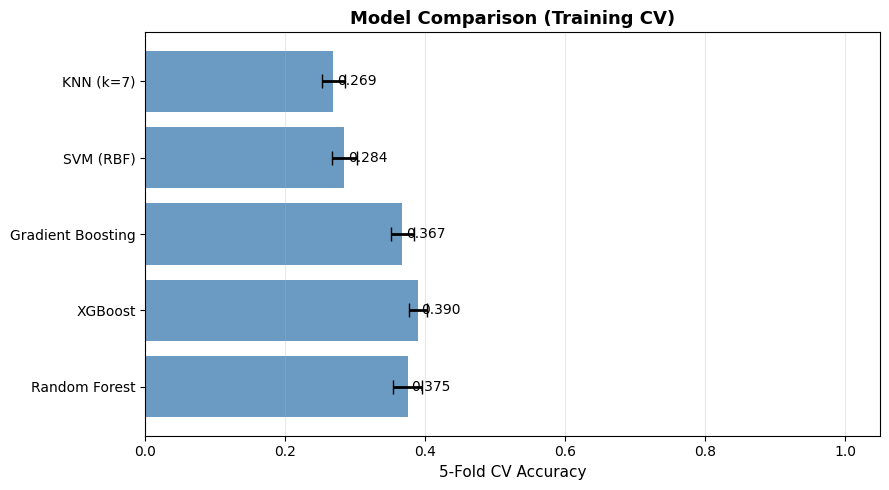

In [34]:
# ── 9. CV comparison bar chart ────────────────────────────────────────────────
means = [cv_results[m].mean() for m in MODELS]
stds  = [cv_results[m].std()  for m in MODELS]
names = list(MODELS.keys())

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(names, means, xerr=stds, color='steelblue', alpha=0.8,
               error_kw=dict(elinewidth=2, capsize=5))
ax.set_xlim(0, 1.05)
ax.set_xlabel('5-Fold CV Accuracy', fontsize=11)
ax.set_title('Model Comparison (Training CV)', fontsize=13, fontweight='bold')
for bar, mean in zip(bars, means):
    ax.text(mean + 0.005, bar.get_y() + bar.get_height()/2,
            f'{mean:.3f}', va='center', fontsize=10)
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

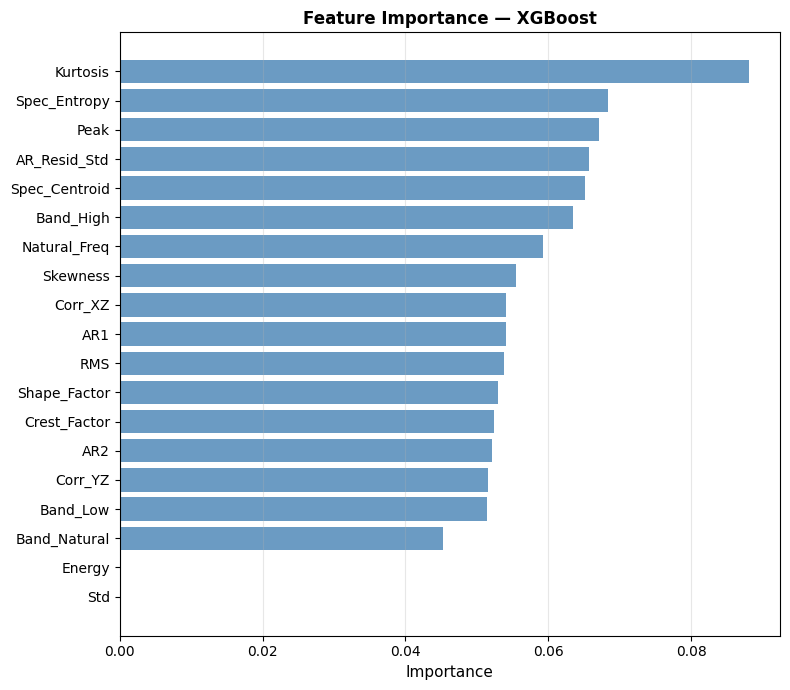


Top 5 features:
      Feature  Importance
     Kurtosis    0.088026
 Spec_Entropy    0.068332
         Peak    0.067039
 AR_Resid_Std    0.065719
Spec_Centroid    0.065071


In [35]:
# ── 10. Feature importance (if RF or XGBoost) ─────────────────────────────────
if hasattr(best_model, 'feature_importances_'):
    imp = pd.DataFrame({'Feature': FEATURES,
                        'Importance': best_model.feature_importances_})\
            .sort_values('Importance', ascending=True)

    fig, ax = plt.subplots(figsize=(8, 7))
    ax.barh(imp['Feature'], imp['Importance'], color='steelblue', alpha=0.8)
    ax.set_xlabel('Importance', fontsize=11)
    ax.set_title(f'Feature Importance — {best_name}', fontsize=12, fontweight='bold')
    ax.grid(True, axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('\nTop 5 features:')
    print(imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))
else:
    print(f'{best_name} does not expose feature importances directly.')

In [37]:
# ── 11. Save artefacts ────────────────────────────────────────────────────────
joblib.dump(best_model, 'shm_model.pkl')
joblib.dump(scaler,     'scaler.pkl')
joblib.dump(le,         'label_encoder.pkl')
joblib.dump(FEATURES,   'features.pkl')

print('Saved:')
print('  shm_model.pkl     — trained classifier')
print('  scaler.pkl        — fitted StandardScaler')
print('  label_encoder.pkl — class name mapping')
print('  features.pkl      — ordered feature list')
print(f'\nBest model: {best_name}')
print(f'CV accuracy: {cv_results[best_name].mean():.4f} ± {cv_results[best_name].std():.4f}')
print(f'Test accuracy: {test_acc:.4f}')

Saved:
  shm_model.pkl     — trained classifier
  scaler.pkl        — fitted StandardScaler
  label_encoder.pkl — class name mapping
  features.pkl      — ordered feature list

Best model: XGBoost
CV accuracy: 0.3896 ± 0.0125
Test accuracy: 0.3854
